In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
df = pd.read_csv('StudentsPerformance.csv')

print('Shape of dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape of dataset: (1000, 8)

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
df['total score']=df['math score'] + df['reading score'] + df['writing score']
df['average score']= (df['total score']/3). round (2)
print ('average score overall:' , df['average score'].mean().round(2))
print ('high score:', df['total score']. max())
print ('lowest score:', df['total score'].min())


average score overall: 67.77
high score: 300
lowest score: 27


In [12]:
gender_avg = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean().round(2)
print('Average scores by Gender:')
print(gender_avg)

Average scores by Gender:
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31


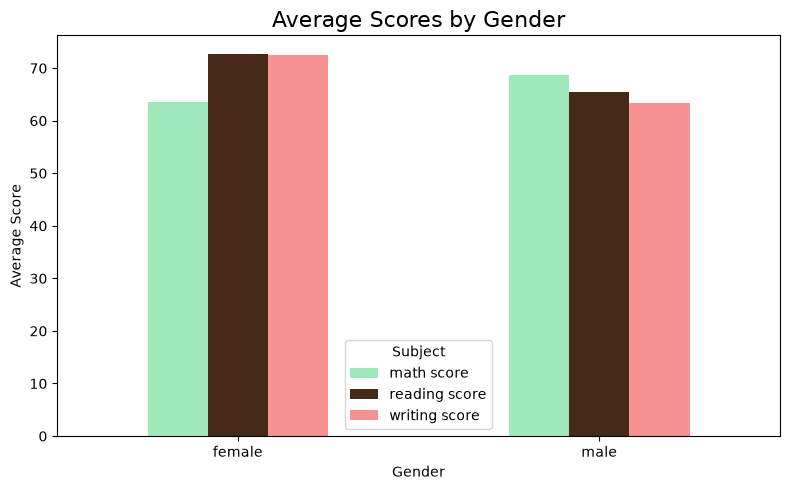

In [18]:
gender_avg.plot(kind='bar', figsize=(8, 5), color=["#9FE8B9", "#472918", "#F59393"])
plt.title('Average Scores by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

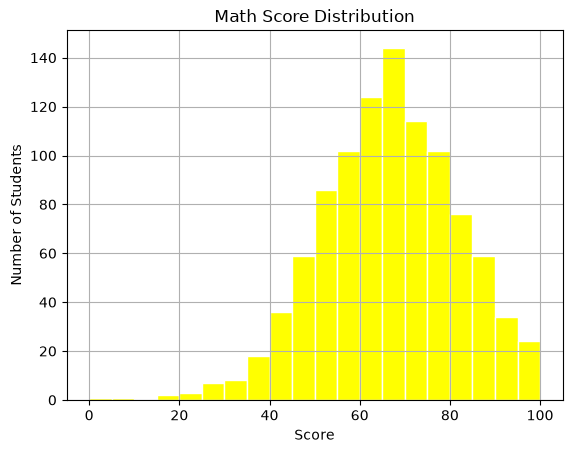

In [16]:
df['math score'].hist(bins=20, color='yellow', edgecolor='white')
plt.title('Math Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.show()

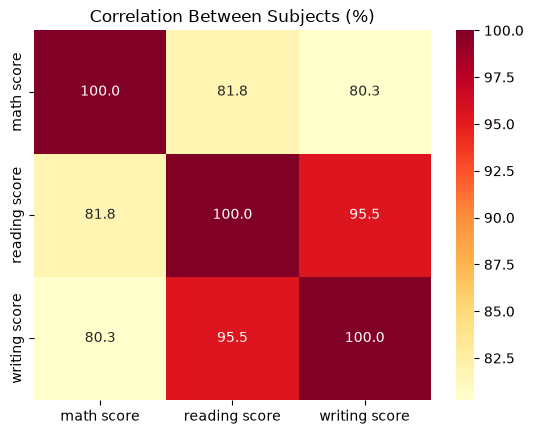

In [20]:
corr = df[['math score', 'reading score', 'writing score']].corr() * 100

sns.heatmap(corr, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Correlation Between Subjects (%)')
plt.show()

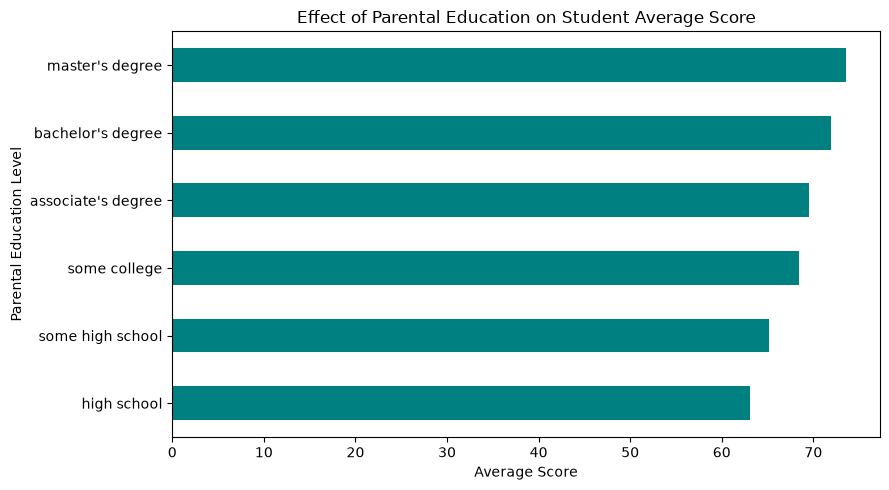

In [21]:
parent_avg = df.groupby('parental level of education')['average score'].mean().sort_values(ascending=True)

parent_avg.plot(kind='barh', figsize=(9, 5), color='teal')
plt.title('Effect of Parental Education on Student Average Score')
plt.xlabel('Average Score')
plt.ylabel('Parental Education Level')
plt.tight_layout()
plt.show()

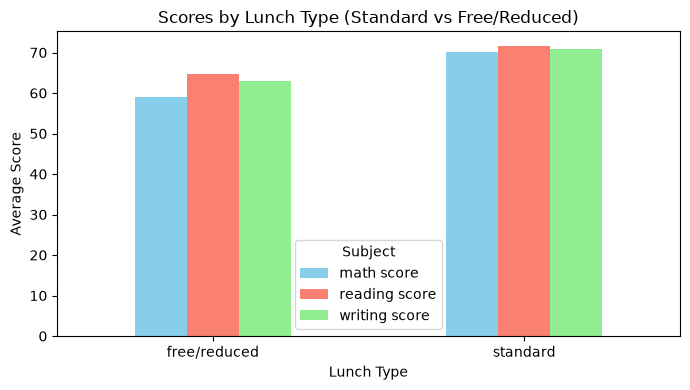

In [22]:
lunch_avg = df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean().round(2)

lunch_avg.plot(kind='bar', figsize=(7, 4), color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Scores by Lunch Type (Standard vs Free/Reduced)')
plt.xlabel('Lunch Type')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

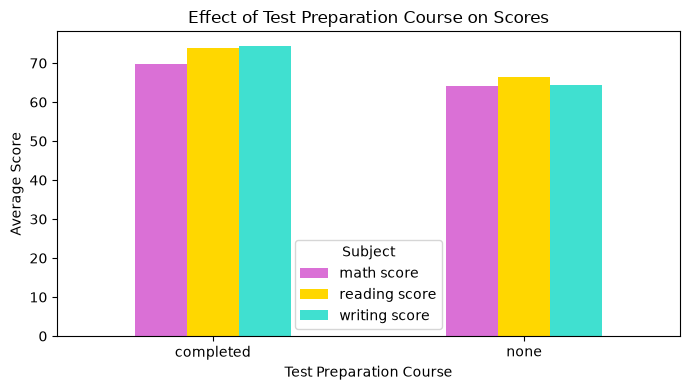

In [23]:
prep_avg = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean().round(2)

prep_avg.plot(kind='bar', figsize=(7, 4), color=['orchid', 'gold', 'turquoise'])
plt.title('Effect of Test Preparation Course on Scores')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

## Key Findings

1. **Reading and Writing scores are highly correlated (0.95)** — students who do well in 
   reading tend to do equally well in writing, since both rely on similar language skills.

2. **Parental education matters** — students whose parents completed a bachelor's or 
   master's degree consistently scored higher across all subjects.

3. **Lunch type (income indicator) shows a clear gap** — students with standard lunch 
   scored 8-12 points higher on average than those with free/reduced lunch, suggesting 
   socioeconomic background impacts academic performance.

4. **Test preparation course improves scores** — students who completed a prep course 
   scored 6-10 points higher across all subjects compared to those who didn't.

5. **Math has the widest score variation** — unlike reading/writing, math scores spread 
   out more, suggesting it's a more challenging or inconsistent subject for students.